<a href="https://colab.research.google.com/github/Megh-05/Data-Science/blob/main/Exp_No_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Train Dataset Shape : (25000, 250)
Test Dataset Shape : (25000, 250)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 250, 100)       │     1,200,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 250, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,288,641 (4.92 MB)

 Trainable params: 1,288,641 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 148s 915ms/step - accuracy: 0.7375 - loss: 0.5109 - val_accuracy: 0.8422 - val_loss: 0.3790
Epoch 2/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 140s 895ms/step - accuracy: 0.8878 - loss: 0.2878 - val_accuracy: 0.8790 - val_loss: 0.3149
Epoch 3/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 144s 903ms/step - accuracy: 0.9268 - loss: 0.2026 - val_accuracy: 0.8686 - val_loss: 0.3344
Epoch 4/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 153s 973ms/step - accuracy: 0.9424 - loss: 0.1628 - val_accuracy: 0.8664 - val_loss: 0.3772
782/782 ━━━━━━━━━━━━━━━━━━━━ 54s 69ms/step - accuracy: 0.8532 - loss: 0.4004

IMDB Review Classification Accuracy : 0.85316002368927


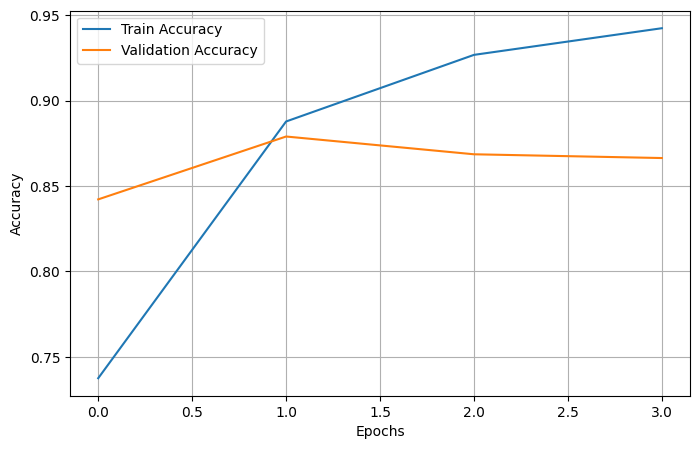

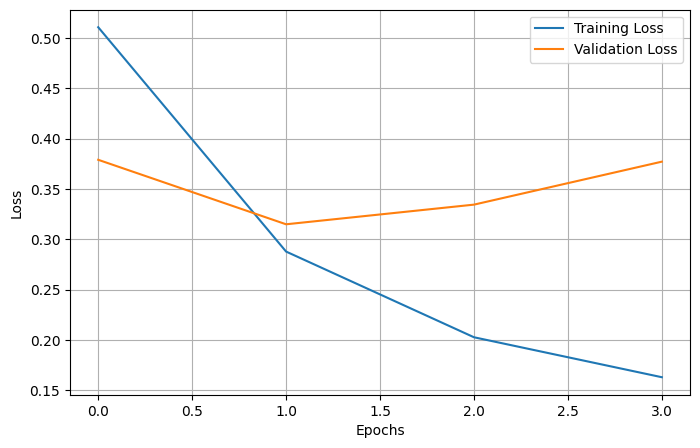

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    SpatialDropout1D,
    Bidirectional
)

# Total Vocabulary Words

total_words = 12000

# Load IMDB Review Dataset

(train_reviews, train_labels), (test_reviews, test_labels) = imdb.load_data(
    num_words=total_words
)

# Sequence Length

review_length = 250

# Apply Padding

train_reviews = pad_sequences(
    train_reviews,
    maxlen=review_length,
    padding='post'
)

test_reviews = pad_sequences(
    test_reviews,
    maxlen=review_length,
    padding='post'
)

print("Train Dataset Shape :", train_reviews.shape)
print("Test Dataset Shape :", test_reviews.shape)

# Create Sequential NLP Model

sentiment_model = Sequential()

# Word Embedding Layer

sentiment_model.add(
    Embedding(
        input_dim=total_words,
        output_dim=100,
        input_shape=(review_length,)
    )
)

# Dropout for Embedding

sentiment_model.add(
    SpatialDropout1D(0.3)
)

# Bidirectional LSTM Layer

sentiment_model.add(
    Bidirectional(
        LSTM(64)
    )
)

# Hidden Dense Layer

sentiment_model.add(
    Dense(
        32,
        activation='relu'
    )
)

# Final Output Layer

sentiment_model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

# Display Model Information

sentiment_model.summary()

# Compile Deep Learning Model

sentiment_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model

training_output = sentiment_model.fit(
    train_reviews,
    train_labels,
    epochs=4,
    batch_size=128,
    validation_split=0.2
)

# Evaluate Model

evaluation_loss, evaluation_accuracy = sentiment_model.evaluate(
    test_reviews,
    test_labels
)

print("\nIMDB Review Classification Accuracy :", evaluation_accuracy)

# Accuracy Plot

plt.figure(figsize=(8, 5))

plt.plot(
    training_output.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    training_output.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.grid(True)

plt.show()

# Loss Plot

plt.figure(figsize=(8, 5))

plt.plot(
    training_output.history['loss'],
    label='Training Loss'
)

plt.plot(
    training_output.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.grid(True)

plt.show()